# Modell zur Ausgabenkategorisierung

Hybrider Ansatz aus **Speicher**, **Regeln** und einem **lokalen LLM** (`qwen2.5:3b` über Ollama).
Ziel: präzise Kategorien bei möglichst wenigen LLM-Abfragen. Alle Daten bleiben lokal.

**Pipeline pro Transaktion:**

1. **Normalisieren** – Payee wird bereinigt (Kleinschreibung, Umlaute, Zahlen, Satzzeichen, URLs, Ortsnamen).
2. **Speicher** – Treffer in der SQLite-Tabelle bekannter Händler? → Kategorie übernehmen.
3. **Regeln** – sonst: Schlüsselwortregeln (Supermärkte, Streaming, Verkehr, ...).
4. **LLM** – sonst: lokales LLM ordnet die Transaktion einer Kategorie zu.
5. **Speichern** – das Ergebnis landet im Speicher und wird beim nächsten Mal direkt wiederverwendet.

Manuelle Korrekturen überschreiben den Speichereintrag, sodass sich das System an das
individuelle Ausgabeverhalten anpasst.

## 1. Setup

Modell vorab laden: `ollama pull qwen2.5:3b`

`ExpenseDatabase` (in `Expanse_Class.py`) kapselt SQLite: Kategorien, Keyword-Regeln,
Händler-Speicher und Korrekturen. Kategorien und Keywords werden einmalig gesetzt – dafür
`init_categories.py` anpassen und im Terminal ausführen:

```bash
python init_categories.py
```
oder
```bash
python3 init_categories.py
```

`city_names` enthält alle Städtenamen (akzentfrei, klein) und dient später zum Herausfiltern
von Ortsangaben aus dem Payee.

In [1]:
import json
import re
import sys
import unicodedata
from pathlib import Path
from string import Template

import geonamescache
import matplotlib.pyplot as plt
import numpy as np
import ollama
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

from Expanse_Class import ExpenseDatabase

# DKB-Parser aus dem Backend, um echte Testdaten zu laden
sys.path.append("../../")
from backend.parsers import DKB

gc = geonamescache.GeonamesCache()

city_names = {
    "".join(
        c for c in unicodedata.normalize("NFKD", city["name"].lower())
        if not unicodedata.combining(c)
    )
    for city in gc.get_cities().values()
}

## 2. Textnormalisierung

`clean_payee` macht aus verschiedenen Schreibweisen desselben Händlers einen einheitlichen Schlüssel,
z. B. `ALDI SUED FIL.017 KIEL` → `aldi sued fil`.

> ⚠️ Der letzte Schritt entfernt **jedes** Wort, das ein Städtename ist. Marken, die wie eine
> (auch ausländische) Stadt heißen, können dadurch verloren gehen.

In [2]:
def clean_payee(text: str) -> str:
    """
    Normalisiert einen Payee-String:
    Kleinschreibung, ohne Akzente, URLs, alleinstehende Zahlen,
    Sonderzeichen, Satzzeichen, Ortsnamen und Mehrfach-Leerzeichen.
    """
    if pd.isna(text):
        return ""

    text = str(text).lower().strip()

    # Akzente entfernen (ä -> a, é -> e, ...)
    text = unicodedata.normalize("NFKD", text)
    text = "".join(c for c in text if not unicodedata.combining(c))

    text = re.sub(r"\.com\b|\.co\.uk\b|www\.", " ", text)  # URLs / Domains
    text = re.sub(r"\b\d+\b", " ", text)                    # alleinstehende Zahlen
    text = re.sub(r"[*#]", " ", text)                       # Sonderzeichen
    text = re.sub(r"[^\w\s]", " ", text)                    # Satzzeichen
    text = re.sub(r"\s+", " ", text).strip()                # Leerzeichen

    # Ortsnamen entfernen
    return " ".join(w for w in text.split() if w not in city_names)

## 3. LLM-Fallback

Wird nur aufgerufen, wenn weder Speicher noch Regeln greifen.

Der Prompt liegt in `prompts/classify_transaction.txt` und wird einmalig geladen. Er gibt dem
Modell drei Dinge vor: Zahlungsdienstleister und Banking-Rauschen ignorieren, den **echten
Händler** kategorisieren (`PAYPAL *SPOTIFY` → `abos`, nicht PayPal) und die Antwort als striktes
JSON zurückgeben (`format="json"`).

Platzhalter im Template: `$categories` (kommt aus `db.build_prompt()`) und `$description`.
Wir nutzen `string.Template` statt f-String, damit die JSON-Klammern im Prompt nicht
verdoppelt werden müssen.

In [3]:
PROMPT_TEMPLATE = Template(
    Path("prompts/classify_transaction.txt").read_text(encoding="utf-8")
)


def classify_with_llm(description, db):
    prompt = PROMPT_TEMPLATE.substitute(
        categories=db.build_prompt(),
        description=description,
    )

    response = ollama.chat(
        model="qwen2.5:3b",
        messages=[{"role": "user", "content": prompt}],
        format="json",
    )

    result = json.loads(response["message"]["content"])

    return {
        "category": result["category"],
        "confidence": float(result["confidence"]),
        "source": "llm",
    }

## 4. Klassifikations-Pipeline

`classify_expenses` läuft über alle Zeilen und probiert der Reihe nach: Speicher → Regeln → LLM.
Das Ergebnis wird unter dem normalisierten Händlernamen gespeichert und landet in drei neuen Spalten:
`category`, `confidence`, `classification_source`.

In [4]:
def classify_expenses(df):
    db = ExpenseDatabase()
    results = []

    for _, row in df.iterrows():
        description = row["classifier"]

        result = (
            db.lookup_memory(description)
            or db.apply_rules(description)
            or classify_with_llm(clean_payee(description), db)
        )

        # Ergebnis für zukünftige Transaktionen merken
        db.save_memory(clean_payee(description), result["category"], result["confidence"])
        results.append(result)

    output = df.copy()
    output["category"] = [r["category"] for r in results]
    output["confidence"] = [r["confidence"] for r in results]
    output["classification_source"] = [r["source"] for r in results]

    db.close()
    return output

## 5. Manuelle Korrektur

Überschreibt den Speichereintrag eines Händlers. Alle künftigen Transaktionen desselben
Händlers erhalten automatisch die korrigierte Kategorie.

In [5]:
def correct_transaction(df, index, new_category, db):
    """Korrigiert eine Transaktion manuell und merkt sich die Kategorie."""
    merchant = clean_payee(df.loc[index, "classifier"])
    db.correct_merchant(merchant, new_category)

## 6. Test der Pipeline

Synthetische, bereits kategorisierte DKB-Daten. `classifier` ist der Text, den die Pipeline sieht
(Payee + Verwendungszweck). Aus der wahren Kategorie wird die führende Nummerierung (`1. `) entfernt.

In [6]:
transactions = DKB.load("../../data/dkb_synth_large.csv")

transactions["classifier"] = transactions["payee"] + " " + transactions["description"]
transactions["category"] = transactions["category"].str.replace(r"^\d+\.\s*", "", regex=True)

result = classify_expenses(transactions.head(50))

print(result[["classifier", "category", "confidence", "classification_source"]].head(20))

                                           classifier       category  \
0                     Lucky Luke Beitrag zum Geschenk  lifestyle&fun   
1            1und1 DSL Rechnung 06/2026 Kd-Nr. 059784                  
2   PayPal Europe S.a.r.l. et Cie S.C.A 9946418398...       mobility   
3   Deutsche Glasfaser Rechnung 10/2025 Kd-Nr. 951...       mobility   
4   Spargelhof.Klein.0047/Düsseldorf SPARGELHOF SA...      groceries   
5   Rossmann Babywelt Lastschrift 10/2025 Ref 1705...      groceries   
6         wilhelm.tel Rechnung 06/2026 Kd-Nr. 7801104    fixed costs   
7           KVB Köln Lastschrift 09/2025 Ref 79736383                  
8   PayPal Europe S.a.r.l. et Cie S.C.A 6355373096...       mobility   
9   PayPal Europe S.a.r.l. et Cie S.C.A 1584668793...     healthcare   
10  Hotel.Astoria.124/Köln HOTEL 2025-08-14T16:29:...  lifestyle&fun   
11  PayPal Europe S.a.r.l. et Cie S.C.A 4510173973...      groceries   
12  PayPal Europe S.a.r.l. et Cie S.C.A 6198273481...  subscript

## 7. Vergleich: Vorhersage vs. tatsächliche Kategorie


In [7]:
comparison = result.merge(
    transactions[["classifier", "category"]],
    on="classifier",
    suffixes=("_predicted", "_true"),
)

comparison["correct"] = comparison["category_predicted"] == comparison["category_true"]

accuracy = comparison["correct"].mean()
correct = comparison["correct"].sum()
total = len(comparison)

print(f"Accuracy: {accuracy:.2%}")
print(f"Correct: {correct}/{total}")
print(f"Wrong:   {total - correct}/{total}")

Accuracy: 46.00%
Correct: 23/50
Wrong:   27/50


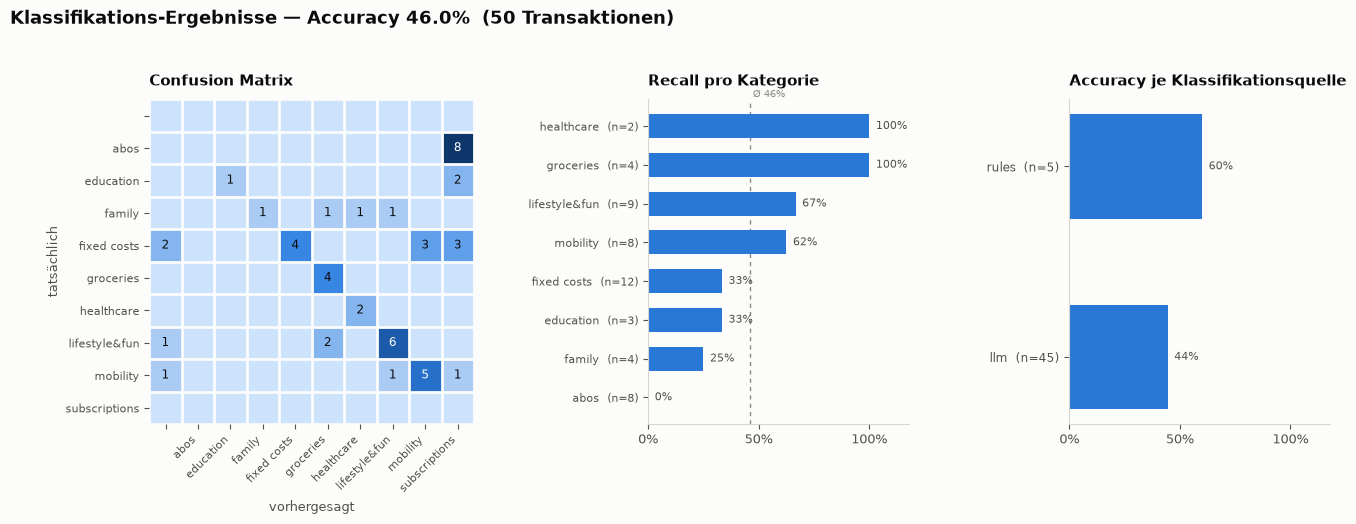

Häufigste Verwechslungen (tatsächlich -> vorhergesagt):
category_true  category_predicted
abos           subscriptions         8
fixed costs    mobility              3
               subscriptions         3
education      subscriptions         2
fixed costs                          2
lifestyle&fun  groceries             2
family         groceries             1
               healthcare            1


In [8]:
# ---- Design-Tokens: eine Farbfamilie (blau), Text bleibt Tinte ----
SURFACE, INK, INK_2, INK_MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#8a8983", "#d6d5d0"
ACCENT = "#2a78d6"
SEQ = LinearSegmentedColormap.from_list("blue", [
    "#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
    "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b",
])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK_2, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRID, "xtick.color": INK_2, "ytick.color": INK_2,
})

cats = sorted(set(comparison["category_true"]) | set(comparison["category_predicted"]))

fig = plt.figure(figsize=(13.5, 5.6))
gs = fig.add_gridspec(1, 3, width_ratios=[1.35, 1, 1], wspace=0.55)

# ---------- 1. Confusion Matrix ----------
ax = fig.add_subplot(gs[0])
cm = pd.crosstab(
    comparison["category_true"], comparison["category_predicted"]
).reindex(index=cats, columns=cats, fill_value=0)

ax.imshow(cm.values, cmap=SEQ, vmin=0, vmax=cm.values.max())
for i in range(len(cats)):
    for j in range(len(cats)):
        v = cm.values[i, j]
        if v:
            ax.text(j, i, v, ha="center", va="center", fontsize=8.5,
                    color="#ffffff" if v / cm.values.max() > 0.55 else INK)

ax.set_xticks(range(len(cats)), cats, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(cats)), cats, fontsize=8)
ax.set_xlabel("vorhergesagt")
ax.set_ylabel("tatsächlich")
ax.set_title("Confusion Matrix", loc="left", fontweight="bold", pad=10)
# 2px-Lücke in Surface-Farbe zwischen den Zellen
ax.set_xticks(np.arange(-0.5, len(cats), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(cats), 1), minor=True)
ax.grid(which="minor", color=SURFACE, linewidth=2)
ax.tick_params(which="minor", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# ---------- 2. Recall pro Kategorie ----------
ax = fig.add_subplot(gs[1])
recall = comparison.groupby("category_true")["correct"].mean().sort_values()
support = comparison["category_true"].value_counts()

ax.barh(range(len(recall)), recall.values, color=ACCENT, height=0.62)
ax.set_yticks(range(len(recall)),
              [f"{c}  (n={support[c]})" for c in recall.index], fontsize=8)
for i, v in enumerate(recall.values):
    ax.text(v + 0.03, i, f"{v:.0%}", va="center", fontsize=8, color=INK_2)

ax.axvline(accuracy, color=INK_MUTED, lw=1, ls=(0, (3, 3)), zorder=0)
ax.text(accuracy, len(recall) - 0.25, f" Ø {accuracy:.0%}", fontsize=7.5, color=INK_MUTED)
ax.set_xlim(0, 1.18)
ax.set_xticks([0, 0.5, 1], ["0%", "50%", "100%"])
ax.set_title("Recall pro Kategorie", loc="left", fontweight="bold", pad=10)
ax.spines["left"].set_color(GRID)

# ---------- 3. Accuracy je Klassifikationsquelle ----------
ax = fig.add_subplot(gs[2])
src = comparison.groupby("classification_source")["correct"].agg(
    acc="mean", n="size").sort_values("acc")

ax.barh(range(len(src)), src["acc"].values, color=ACCENT, height=0.55)
ax.set_yticks(range(len(src)),
              [f"{s}  (n={int(src['n'][s])})" for s in src.index], fontsize=8.5)
for i, v in enumerate(src["acc"].values):
    ax.text(v + 0.03, i, f"{v:.0%}", va="center", fontsize=8, color=INK_2)

ax.set_xlim(0, 1.18)
ax.set_xticks([0, 0.5, 1], ["0%", "50%", "100%"])
ax.set_title("Accuracy je Klassifikationsquelle", loc="left", fontweight="bold", pad=10)
ax.spines["left"].set_color(GRID)

fig.suptitle(
    f"Klassifikations-Ergebnisse — Accuracy {accuracy:.1%}  ({len(comparison)} Transaktionen)",
    x=0.007, ha="left", fontsize=13, fontweight="bold",
)
fig.subplots_adjust(top=0.82, bottom=0.24, left=0.10, right=0.985)
plt.show()

# Tabellen-Ansicht: die größten Verwechslungen
errors = (comparison[~comparison["correct"]]
          .groupby(["category_true", "category_predicted"]).size()
          .sort_values(ascending=False).rename("n"))
print("Häufigste Verwechslungen (tatsächlich -> vorhergesagt):")
print(errors.head(8).to_string())